In [1]:
import os
import librosa
import numpy as np
import pandas as pd

def read_dataset_with_labels(data_path, reference_path, fixed_length=130):
    mfccs = []
    labels = []

    # Load reference.csv to extract labels
    try:
        # Read the CSV file without headers
        reference_df = pd.read_csv(reference_path, header=None)
        
        # Manually assign column names
        reference_df.columns = ['filename', 'label']
        
        # Append '.wav' to filenames to match audio file names
        reference_df['filename'] += '.wav'
        
        # Set filenames as the index for quick lookup
        reference_df.set_index('filename', inplace=True)
    except Exception as e:
        raise FileNotFoundError(f"Could not read reference CSV: {e}")
    
    # Get all files in sorted order
    file_list = sorted(os.listdir(data_path))
    
    # Iterate over audio files in sorted order
    for file in file_list:
        if file.endswith('.wav'):
            file_path = os.path.join(data_path, file)
            # print(f"Processing file: {file_path}")  # Debugging line
            
            try:
                # Load the audio file
                y, sr = librosa.load(file_path, sr=None)
                
                # Extract MFCC features
                mfcc = librosa.feature.mfcc(y=y, sr=sr)
                
                # Pad or truncate MFCCs to a fixed length
                if mfcc.shape[1] < fixed_length:
                    padding = fixed_length - mfcc.shape[1]
                    mfcc = np.pad(mfcc, ((0, 0), (0, padding)), mode='constant')
                else:
                    mfcc = mfcc[:, :fixed_length]
                
                # Append flattened MFCC features
                mfccs.append(mfcc.flatten())
                
                # Retrieve label from reference.csv
                if file in reference_df.index:
                    label = reference_df.loc[file, 'label']
                    labels.append(label)
                else:
                    print(f"Label for {file} not found in reference.csv. Skipping.")
            
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
    
    # Ensure that mfccs and labels are populated
    if len(mfccs) == 0:
        raise ValueError("No valid MFCC data found. Please check the dataset.")

    return np.array(mfccs), np.array(labels)


all_mfccs = []
all_labels = []

# Process all folders
folders = ['training-a', 'training-b', 'training-c', 'training-d', 'training-e', 'training-f']
base_path = '/kaggle/input/physionet-challenge-2016'

for folder in folders:
    data_path = os.path.join(base_path, folder)
    reference_path = os.path.join(data_path, 'REFERENCE.csv')
    
    # Extract MFCCs and labels for the current folder
    folder_mfccs, folder_labels = read_dataset_with_labels(data_path, reference_path)
    
    # Combine data from all folders
    all_mfccs.extend(folder_mfccs)
    all_labels.extend(folder_labels)

# Convert to numpy arrays for consistency
all_mfccs = np.array(all_mfccs)
all_labels = np.array(all_labels)

# Check the shapes of the combined data
print(f"Total MFCC shape: {all_mfccs.shape}, Total Labels shape: {all_labels.shape}")

# Save combined features and labels for future use
np.save('mfcc_features.npy', all_mfccs)
np.save('labels.npy', all_labels)

Total MFCC shape: (3240, 2600), Total Labels shape: (3240,)


In [2]:
print(all_mfccs[1])
print(all_labels[1])

[-268.50842 -218.85402 -224.99608 ...    0.         0.         0.     ]
1


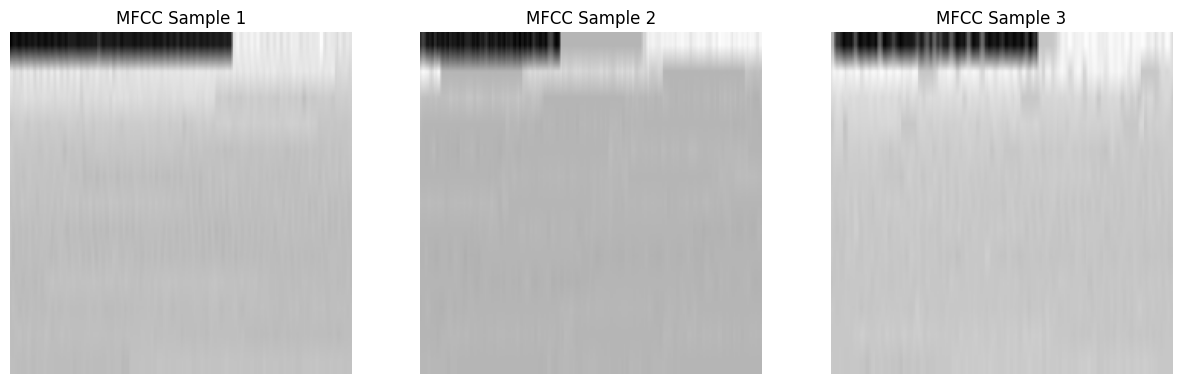

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

def mfcc_to_rgb(mfcc, target_size=(224, 224)):
    
    # Normalize MFCC values to range [0, 255] for image representation
    mfcc_normalized = 255 * (mfcc - np.min(mfcc)) / (np.max(mfcc) - np.min(mfcc))
    
    # Resize the MFCC to the desired target size
    resized_mfcc = cv2.resize(mfcc_normalized, target_size, interpolation=cv2.INTER_LINEAR)
    
    # Convert single-channel to 3-channel by replicating across R, G, and B
    rgb_image = np.stack([resized_mfcc] * 3, axis=-1).astype(np.uint8)
    
    return rgb_image

def display_images(mfcc_features, num_images=3, target_size=(224, 224)):
   
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        mfcc = mfcc_features[i]  # Already reshaped
        rgb_image = mfcc_to_rgb(mfcc, target_size)
        
        # Plot the RGB image
        plt.subplot(1, num_images, i + 1)
        plt.imshow(rgb_image)
        plt.title(f"MFCC Sample {i + 1}")
        plt.axis('off')
    plt.show()

# Parameters
n_mfcc = 13  # Number of MFCC coefficients
num_samples = all_mfccs.shape[0]
flattened_dim = all_mfccs.shape[1]

# Calculate time steps
time_steps = flattened_dim // n_mfcc
if flattened_dim % n_mfcc != 0:
    raise ValueError(f"Inconsistent dimensions: Cannot reshape {flattened_dim} into (13, time_steps).")

# Reshape MFCCs to 2D (n_mfcc, time_steps)
all_mfccs_reshaped = all_mfccs.reshape((num_samples, n_mfcc, time_steps))

# Display 2-3 images from the dataset
display_images(all_mfccs_reshaped, num_images=3, target_size=(224, 224))


In [4]:
import os
import librosa
import numpy as np
import pandas as pd

def read_dataset_with_labels(data_path, reference_path, fixed_length=130, n_mels=128):
    mel_specs = []
    labels = []

    # Load reference.csv to extract labels
    try:
        # Read the CSV file without headers
        reference_df = pd.read_csv(reference_path, header=None)
        
        # Manually assign column names
        reference_df.columns = ['filename', 'label']
        
        # Append '.wav' to filenames to match audio file names
        reference_df['filename'] += '.wav'
        
        # Set filenames as the index for quick lookup
        reference_df.set_index('filename', inplace=True)
    except Exception as e:
        raise FileNotFoundError(f"Could not read reference CSV: {e}")
    
    # Get all files in sorted order
    file_list = sorted(os.listdir(data_path))
    
    # Iterate over audio files in sorted order
    for file in file_list:
        if file.endswith('.wav'):
            file_path = os.path.join(data_path, file)
            try:
                # Load the audio file
                y, sr = librosa.load(file_path, sr=None)
                
                # Extract Mel Spectrogram features
                mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
                
                # Convert to decibel scale for better visualization
                mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
                
                # Pad or truncate Mel Spectrogram to a fixed length
                if mel_spec_db.shape[1] < fixed_length:
                    padding = fixed_length - mel_spec_db.shape[1]
                    mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, padding)), mode='constant')
                else:
                    mel_spec_db = mel_spec_db[:, :fixed_length]
                
                # Append the Mel Spectrogram
                mel_specs.append(mel_spec_db)
                
                # Retrieve label from reference.csv
                if file in reference_df.index:
                    label = reference_df.loc[file, 'label']
                    labels.append(label)
                else:
                    print(f"Label for {file} not found in reference.csv. Skipping.")
            
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
    
    # Ensure that Mel Spectrograms and labels are populated
    if len(mel_specs) == 0:
        raise ValueError("No valid Mel Spectrogram data found. Please check the dataset.")

    return np.array(mel_specs), np.array(labels)


all_mel_specs = []
all_labels = []

# Process all folders
folders = ['training-a', 'training-b', 'training-c', 'training-d', 'training-e', 'training-f']
base_path = '/kaggle/input/physionet-challenge-2016'

for folder in folders:
    data_path = os.path.join(base_path, folder)
    reference_path = os.path.join(data_path, 'REFERENCE.csv')
    
    # Extract Mel Spectrograms and labels for the current folder
    folder_mel_specs, folder_labels = read_dataset_with_labels(data_path, reference_path)
    
    # Combine data from all folders
    all_mel_specs.extend(folder_mel_specs)
    all_labels.extend(folder_labels)

# Convert to numpy arrays for consistency
all_mel_specs = np.array(all_mel_specs)
all_labels = np.array(all_labels)

# Check the shapes of the combined data
print(f"Total Mel Spectrogram shape: {all_mel_specs.shape}, Total Labels shape: {all_labels.shape}")

# Save combined features and labels for future use
np.save('mel_spectrogram_features.npy', all_mel_specs)
np.save('labels.npy', all_labels)


Total Mel Spectrogram shape: (3240, 128, 130), Total Labels shape: (3240,)


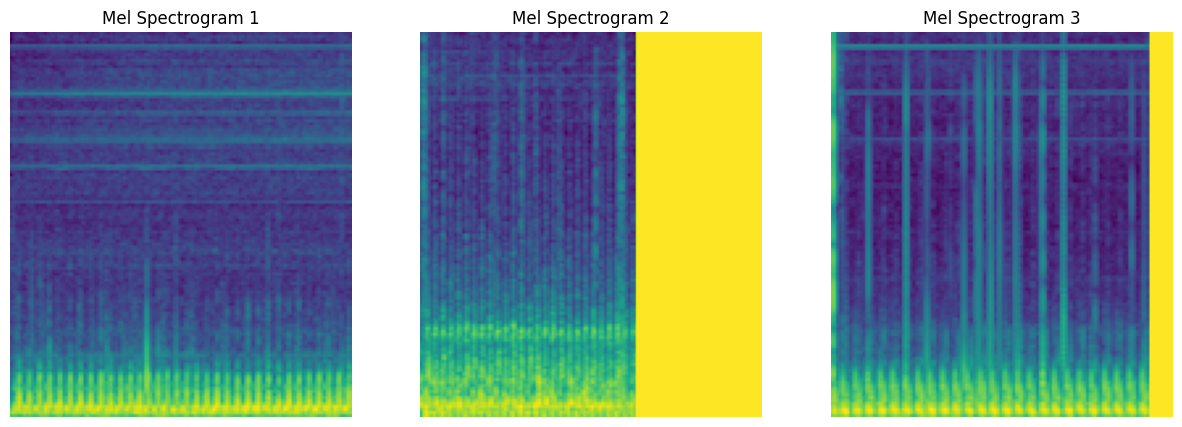

In [5]:
import matplotlib.pyplot as plt

def display_mel_spectrograms(mel_specs, num_images=3):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        mel_spec = mel_specs[i]
        plt.subplot(1, num_images, i + 1)
        plt.imshow(mel_spec, aspect='auto', origin='lower', cmap='viridis')
        plt.title(f"Mel Spectrogram {i + 1}")
        plt.axis('off')
    plt.show()

# Display 2-3 Mel Spectrograms
display_mel_spectrograms(all_mel_specs, num_images=3)


In [1]:
import os
import librosa
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# Constants for audio processing
SAMPLE_RATE = 22050
DURATION = 2  # Duration in seconds
N_MELS = 64
N_FFT = 2048
HOP_LENGTH = 512
FIXED_LENGTH = 87  # Fixed time frames after padding/truncation


# Function to load and preprocess audio into mel spectrogram
def load_and_preprocess_audio(file_path):
    # Load the audio with a fixed sample rate and duration
    audio, _ = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
    # Ensure fixed length by padding or cropping
    if len(audio) < SAMPLE_RATE * DURATION:
        audio = np.pad(audio, (0, SAMPLE_RATE * DURATION - len(audio)))
    else:
        audio = audio[:SAMPLE_RATE * DURATION]
    # Compute the mel spectrogram
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)  # Convert to decibels
    return mel_spec_db


# Data augmentation function
def augment_audio(audio, sr=SAMPLE_RATE, augment_prob=0.5):
    # Time stretching
    if np.random.random() < augment_prob:
        stretch_factor = np.random.uniform(0.8, 1.2)
        audio = librosa.effects.time_stretch(audio, rate=stretch_factor)

    # Pitch shifting
    if np.random.random() < augment_prob:
        n_steps = np.random.randint(-4, 5)  # shift by -4 to 4 semitones
        audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

    # Adding Gaussian noise
    if np.random.random() < augment_prob:
        noise_factor = np.random.uniform(0.005, 0.02)
        noise = np.random.randn(len(audio))
        audio = audio + noise_factor * noise

    # Random gain
    if np.random.random() < augment_prob:
        gain_factor = np.random.uniform(0.8, 1.2)
        audio = audio * gain_factor

    # Randomly crop or pad to maintain fixed duration
    target_length = sr * DURATION
    if len(audio) > target_length:
        start = np.random.randint(0, len(audio) - target_length)
        audio = audio[start:start + target_length]
    elif len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))

    # Clip audio to range [-1, 1]
    audio = np.clip(audio, -1, 1)

    return audio


# PyTorch Dataset for Heart Sound Classification
class HeartSoundDataset(Dataset):
    def __init__(self, file_paths, labels, augment=False, fixed_length=FIXED_LENGTH):
        self.file_paths = file_paths
        self.labels = labels
        self.augment = augment
        self.fixed_length = fixed_length

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Load the audio file
        audio, sr = librosa.load(self.file_paths[idx], sr=SAMPLE_RATE, duration=DURATION)

        # Apply augmentation if enabled
        if self.augment:
            audio = augment_audio(audio, sr=SAMPLE_RATE, augment_prob=0.5)

        # Generate mel spectrogram
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Normalize the spectrogram
        mel_spec_db = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min())

        # Pad or truncate the spectrogram to the fixed length
        if mel_spec_db.shape[1] < self.fixed_length:
            pad_width = self.fixed_length - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_spec_db = mel_spec_db[:, :self.fixed_length]

        label = self.labels[idx]
        return torch.FloatTensor(mel_spec_db).unsqueeze(0), torch.tensor(label)


# Collate function for batching
def collate_fn(batch):
    specs, labels = zip(*batch)
    specs = torch.stack(specs)
    labels = torch.stack(labels)
    return specs, labels

# Helper function to remap labels
def remap_labels(labels):
    return [0 if label == -1 else label for label in labels]

# Function to prepare dataset and labels
def prepare_dataset(data_path, reference_path):
    file_paths = []
    labels = []

    # Load reference.csv to extract labels
    reference_df = pd.read_csv(reference_path, header=None)
    reference_df.columns = ['filename', 'label']
    reference_df['filename'] += '.wav'  # Append '.wav' to match audio files

    # Iterate over files in the data folder
    for file in sorted(os.listdir(data_path)):
        if file.endswith('.wav'):
            file_path = os.path.join(data_path, file)
            if file in reference_df['filename'].values:
                file_paths.append(file_path)
                label = reference_df.loc[reference_df['filename'] == file, 'label'].values[0]
                labels.append(int(label))
    # Remap labels from -1 and 1 to 0 and 1
    labels = remap_labels(labels)
    return file_paths, labels




In [3]:
if __name__ == "__main__":
    # Specify folders and dataset paths
    train_folders = ['training-a', 'training-b', 'training-c', 'training-d', 'training-e', 'training-f']
    validation_folder = 'validation'
    base_path = '/kaggle/input/physionet-challenge-2016'
    
    # Lists to hold file paths and labels for training and validation
    train_file_paths = []
    train_labels = []
    val_file_paths = []
    val_labels = []

    # Process each training folder
    for folder in train_folders:
        data_path = os.path.join(base_path, folder)
        reference_path = os.path.join(data_path, 'REFERENCE.csv')
        file_paths, labels = prepare_dataset(data_path, reference_path)
        train_file_paths.extend(file_paths)
        train_labels.extend(labels)

    # Process validation folder
    validation_data_path = os.path.join(base_path, validation_folder)
    validation_reference_path = os.path.join(validation_data_path, 'REFERENCE.csv')
    val_file_paths, val_labels = prepare_dataset(validation_data_path, validation_reference_path)

    # Create Dataset and DataLoader
    train_dataset = HeartSoundDataset(train_file_paths, train_labels, augment=True)
    val_dataset = HeartSoundDataset(val_file_paths, val_labels, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

    # Display dataset information
    print(f"Train Dataset: {len(train_dataset)} samples")
    print(f"Validation Dataset: {len(val_dataset)} samples")


Train Dataset: 3240 samples
Validation Dataset: 301 samples


In [8]:
print(train_dataset[0])
print(train_dataset[8])


(tensor([[[0.6551, 0.7402, 0.7164,  ..., 0.6499, 0.5050, 0.4249],
         [0.2442, 0.3280, 0.3614,  ..., 0.3396, 0.3607, 0.3074],
         [0.2119, 0.2408, 0.2522,  ..., 0.2165, 0.2248, 0.1830],
         ...,
         [0.1923, 0.2271, 0.2170,  ..., 0.1830, 0.1937, 0.1465],
         [0.1646, 0.2288, 0.2174,  ..., 0.2019, 0.1980, 0.1640],
         [0.1204, 0.2044, 0.2002,  ..., 0.1967, 0.1741, 0.1462]]]), tensor(1))
(tensor([[[0.7734, 0.9965, 1.0000,  ..., 0.3956, 0.3736, 0.3403],
         [0.7406, 0.9156, 0.8294,  ..., 0.3171, 0.2976, 0.2107],
         [0.6287, 0.7475, 0.6563,  ..., 0.2696, 0.2550, 0.1682],
         ...,
         [0.2254, 0.2807, 0.2652,  ..., 0.2899, 0.2639, 0.2010],
         [0.1709, 0.2399, 0.2411,  ..., 0.2647, 0.2359, 0.1485],
         [0.1734, 0.2466, 0.2368,  ..., 0.2637, 0.2500, 0.1865]]]), tensor(0))


# ResNet50

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from tqdm import tqdm

# Define the CNN model with transfer learning
class HeartSoundNet(nn.Module):
    def __init__(self, num_classes):
        super(HeartSoundNet, self).__init__()
        # Load a pre-trained ResNet50 model
        self.resnet = models.resnet50(pretrained=True)
        
        # Modify the first convolutional layer to accept 1-channel input (grayscale)
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Remove the fully connected layer
        self.feature_extractor = nn.Sequential(*list(self.resnet.children())[:-1])
        
        # Add custom classification layers
        self.fc1 = nn.Linear(2048, 512)  # First fully connected layer
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)  # Final classification layer
        # self.fc1 = nn.Sequential(
        #     nn.Linear(2048, 512),
        #     nn.BatchNorm1d(512),
        #     nn.ReLU()
        # )
        # self.dropout = nn.Dropout(0.5)
        
        # self.fc2 = nn.Linear(512, 64)
        # nn.Dropout(0.3)
        # self.fc3 = nn.Linear(64,num_classes)



    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)  # Flatten the feature maps
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        if scheduler:
            scheduler.step(val_acc_epoch)
            
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train Acc: {epoch_acc:.4f}, Val Acc: {val_acc:.4f}")

        # Save the best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print(f"New best model saved with validation accuracy: {val_acc:.4f}")

    return model, train_losses, val_losses, train_accuracies, val_accuracies




In [10]:
# Model setup and training

num_classes = 2  # Adjust based on your dataset (e.g., normal vs. abnormal heart sounds)
learning_rate = 0.0001
num_epochs = 30


model = HeartSoundNet(num_classes=num_classes)
# class_weights = torch.tensor([weight_class_0, weight_class_1], dtype=torch.float).to(device)
# criterion = nn.CrossEntropyLoss(weight=class_weights)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.1)


# Assuming `train_loader` and `val_loader` are already defined
trained_model, train_losses, val_losses, train_acc, val_acc = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs
)


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s] 
Epoch 1/30 - Training: 100%|██████████| 102/102 [02:40<00:00,  1.57s/it]


Epoch 1/30, Train Loss: 0.4216, Val Loss: 0.5942, Train Acc: 0.7994, Val Acc: 0.6944
New best model saved with validation accuracy: 0.6944


Epoch 2/30 - Training: 100%|██████████| 102/102 [02:32<00:00,  1.49s/it]


Epoch 2/30, Train Loss: 0.3526, Val Loss: 0.5676, Train Acc: 0.8265, Val Acc: 0.6777


Epoch 3/30 - Training: 100%|██████████| 102/102 [02:34<00:00,  1.51s/it]


...

Epoch 28/30, Train Loss: 0.1957, Val Loss: 0.2179, Train Acc: 0.9111, Val Acc: 0.8937


Epoch 29/30 - Training: 100%|██████████| 102/102 [02:35<00:00,  1.52s/it]


Epoch 29/30, Train Loss: 0.1739, Val Loss: 0.2248, Train Acc: 0.9272, Val Acc: 0.8937


Epoch 30/30 - Training: 100%|██████████| 102/102 [02:34<00:00,  1.51s/it]


Epoch 30/30, Train Loss: 0.1855, Val Loss: 0.1768, Train Acc: 0.9185, Val Acc: 0.9336
New best model saved with validation accuracy: 0.9336


# EfficientNet-b4

In [11]:
if __name__ == "__main__":
    # Specify folders and dataset paths
    train_folders = ['training-a', 'training-b', 'training-c', 'training-d', 'training-e', 'training-f']
    validation_folder = 'validation'
    base_path = '/kaggle/input/physionet-challenge-2016'
    
    # Lists to hold file paths and labels for training and validation
    train_file_paths = []
    train_labels = []
    val_file_paths = []
    val_labels = []

    # Process each training folder
    for folder in train_folders:
        data_path = os.path.join(base_path, folder)
        reference_path = os.path.join(data_path, 'REFERENCE.csv')
        file_paths, labels = prepare_dataset(data_path, reference_path)
        train_file_paths.extend(file_paths)
        train_labels.extend(labels)

    # Process validation folder
    validation_data_path = os.path.join(base_path, validation_folder)
    validation_reference_path = os.path.join(validation_data_path, 'REFERENCE.csv')
    val_file_paths, val_labels = prepare_dataset(validation_data_path, validation_reference_path)

    # Create Dataset and DataLoader
    train_dataset = HeartSoundDataset(train_file_paths, train_labels, augment=True)
    val_dataset = HeartSoundDataset(val_file_paths, val_labels, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

    # Display dataset information
    print(f"Train Dataset: {len(train_dataset)} samples")
    print(f"Validation Dataset: {len(val_dataset)} samples")


Train Dataset: 3240 samples
Validation Dataset: 301 samples


In [12]:
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from tqdm import tqdm

# Define the CNN model with transfer learning using EfficientNet-B1
class HeartSoundNet(nn.Module):
    def __init__(self, num_classes):
        super(HeartSoundNet, self).__init__()
        # Load a pre-trained EfficientNet-B1 model
        self.efficientnet = timm.create_model('efficientnet_b4', pretrained=True)
        
        # Modify the first convolutional layer to accept 1-channel input (grayscale)
        self.efficientnet.conv_stem = nn.Conv2d(
            1,  # Input channels for grayscale images
            self.efficientnet.conv_stem.out_channels, 
            kernel_size=3, 
            stride=2, 
            padding=1, 
            bias=False
        )
        
        # Replace the classifier to match the number of output classes
        in_features = self.efficientnet.classifier.in_features  # Get input features of classifier
        self.efficientnet.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)  # Final output layer with `num_classes` outputs
        )

    def forward(self, x):
        return self.efficientnet(x)



In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        # Step the scheduler (if provided)
        if scheduler:
            scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train Acc: {epoch_acc:.4f}, Val Acc: {val_acc:.4f}")

        # Save the best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print(f"New best model saved with validation accuracy: {val_acc:.4f}")

    return model, train_losses, val_losses, train_accuracies, val_accuracies


In [14]:
# Model setup and training
num_classes = 2  # Adjust based on your dataset (e.g., normal vs. abnormal heart sounds)
learning_rate = 0.0001
num_epochs = 30

model = HeartSoundNet(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Using ReduceLROnPlateau scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1, verbose=True)

trained_model, train_losses, val_losses, train_acc, val_acc = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler=scheduler
) 

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/30 - Training: 100%|██████████| 102/102 [02:45<00:00,  1.62s/it]


Epoch 1/30, Train Loss: 0.5275, Val Loss: 0.8951, Train Acc: 0.7864, Val Acc: 0.5017
New best model saved with validation accuracy: 0.5017


Epoch 2/30 - Training: 100%|██████████| 102/102 [02:38<00:00,  1.55s/it]


Epoch 2/30, Train Loss: 0.4824, Val Loss: 0.7605, Train Acc: 0.7938, Val Acc: 0.4983


...

Epoch 28/30, Train Loss: 0.3245, Val Loss: 0.4713, Train Acc: 0.8438, Val Acc: 0.7209


Epoch 29/30 - Training: 100%|██████████| 102/102 [02:47<00:00,  1.64s/it]


Epoch 29/30, Train Loss: 0.3173, Val Loss: 0.4767, Train Acc: 0.8414, Val Acc: 0.7176


Epoch 30/30 - Training: 100%|██████████| 102/102 [02:46<00:00,  1.63s/it]


Epoch 30/30, Train Loss: 0.3002, Val Loss: 0.4878, Train Acc: 0.8583, Val Acc: 0.7409


In [15]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, verbose=False, path='best_model.pth'):
        """
        Patience: Number of epochs to wait after the last improvement before stopping.
        Delta: Minimum change in monitored metric to qualify as an improvement.
        """
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        """Save the model when validation loss decreases."""
        if self.verbose:
            print(f"Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model ...")
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


def train_model_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler=None, early_stopper=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if scheduler:
            scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train Acc: {epoch_acc:.4f}, Val Acc: {val_acc:.4f}")

        # Early stopping check
        if early_stopper:
            early_stopper(val_loss, model)
            if early_stopper.early_stop:
                print("Early stopping triggered.")
                break

    return model, train_losses, val_losses, train_accuracies, val_accuracies


In [16]:
# Early stopping and training setup
num_classes = 2  # Adjust based on your dataset
learning_rate = 0.0001
num_epochs = 20

model = HeartSoundNet(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1, verbose=True)

early_stopper = EarlyStopping(patience=10, verbose=True, path='best_model.pth')

trained_model, train_losses, val_losses, train_acc, val_acc = train_model_with_early_stopping(
    model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler=scheduler, early_stopper=early_stopper
)


Epoch 1/20 - Training: 100%|██████████| 102/102 [02:46<00:00,  1.64s/it]


Epoch 1/20, Train Loss: 0.5366, Val Loss: 0.8391, Train Acc: 0.7759, Val Acc: 0.4983
Validation loss decreased (inf --> 0.839119). Saving model ...


Epoch 2/20 - Training: 100%|██████████| 102/102 [02:44<00:00,  1.62s/it]


Epoch 2/20, Train Loss: 0.4944, Val Loss: 0.8043, Train Acc: 0.7944, Val Acc: 0.5050
Validation loss decreased (0.839119 --> 0.804322). Saving model ...


Epoch 3/20 - Training: 100%|██████████| 102/102 [02:38<00:00,  1.56s/it]


...

Epoch 18/20, Train Loss: 0.3913, Val Loss: 0.6938, Train Acc: 0.8142, Val Acc: 0.6744
EarlyStopping counter: 5/10


Epoch 19/20 - Training: 100%|██████████| 102/102 [02:43<00:00,  1.60s/it]


Epoch 19/20, Train Loss: 0.3785, Val Loss: 4.6748, Train Acc: 0.8167, Val Acc: 0.6744
EarlyStopping counter: 6/10


Epoch 20/20 - Training: 100%|██████████| 102/102 [02:40<00:00,  1.57s/it]


Epoch 20/20, Train Loss: 0.3879, Val Loss: 1.0004, Train Acc: 0.8133, Val Acc: 0.6811
EarlyStopping counter: 7/10


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [18]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels

# Evaluate the model and get predictions
all_preds, all_labels = evaluate_model(trained_model, val_loader)


In [19]:
import matplotlib.pyplot as plt
def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
    plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()

def plot_accuracy(train_accuracies, val_accuracies):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train Accuracy')
    plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.show()

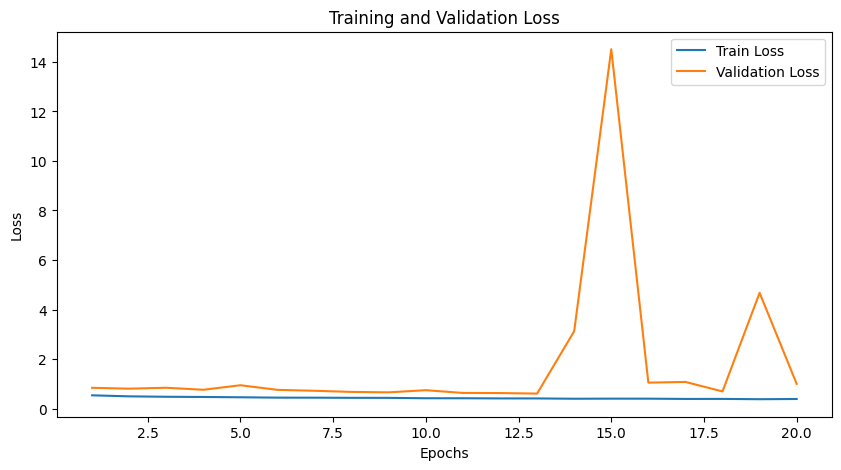

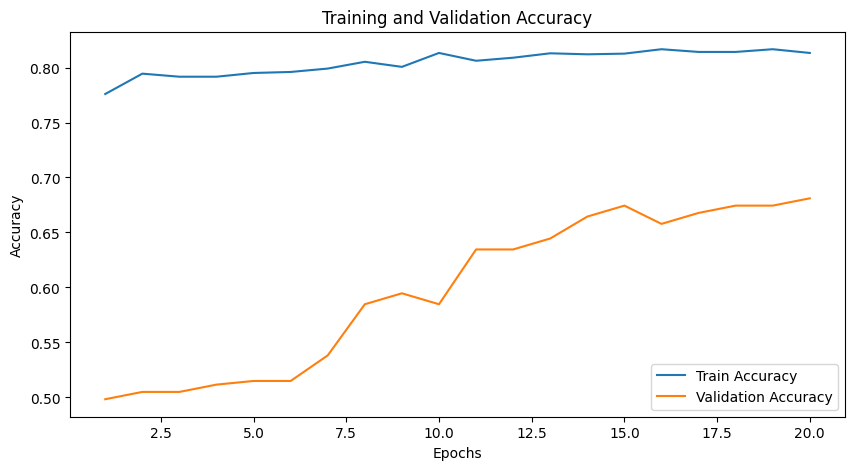

In [20]:

# Plot training and validation loss
plot_loss(train_losses, val_losses)

# Plot training and validation accuracy
plot_accuracy(train_acc, val_acc)

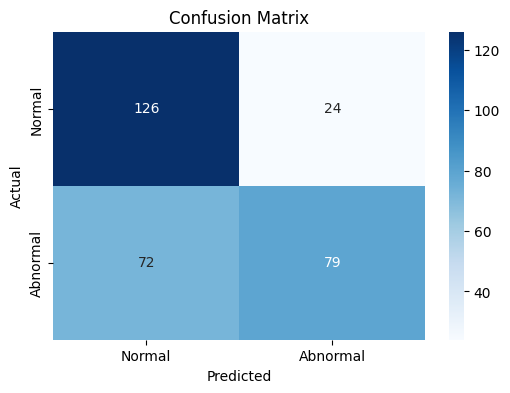

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# Plot the confusion matrix
CLASSES = ['Normal', 'Abnormal']  # Define your class names
plot_confusion_matrix(all_labels, all_preds)


In [ ]:
from sklearn.metrics import roc_curve, auc
def plot_roc_curve(model, data_loader, num_classes):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)  # Logits
            probs = torch.softmax(outputs, dim=1)  # Probabilities

            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    # Concatenate all collected batches
    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    print("Shape of all_labels:", all_labels.shape)
    print("Shape of all_probs:", all_probs.shape)

    # ROC curve computation
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves
    plt.figure(figsize=(6, 4))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random baseline
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()



plot_roc_curve(trained_model, val_loader, 2)


# EfficientNet-b6

In [3]:

# Specify folders and dataset paths
train_folders = ['training-a', 'training-b', 'training-c', 'training-d', 'training-e', 'training-f']
validation_folder = 'validation'
base_path = '/kaggle/input/physionet-challenge-2016'
    
# Lists to hold file paths and labels for training and validation
train_file_paths = []
train_labels = []
val_file_paths = []
val_labels = []

# Process each training folder
for folder in train_folders:
    data_path = os.path.join(base_path, folder)
    reference_path = os.path.join(data_path, 'REFERENCE.csv')
    file_paths, labels = prepare_dataset(data_path, reference_path)
    train_file_paths.extend(file_paths)
    train_labels.extend(labels)

# Process validation folder
validation_data_path = os.path.join(base_path, validation_folder)
validation_reference_path = os.path.join(validation_data_path, 'REFERENCE.csv')
val_file_paths, val_labels = prepare_dataset(validation_data_path, validation_reference_path)

# Create Dataset and DataLoader
train_dataset = HeartSoundDataset(train_file_paths, train_labels, augment=True)
val_dataset = HeartSoundDataset(val_file_paths, val_labels, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

# Display dataset information
print(f"Train Dataset: {len(train_dataset)} samples")
print(f"Validation Dataset: {len(val_dataset)} samples")


Train Dataset: 3240 samples
Validation Dataset: 301 samples


In [7]:
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from tqdm import tqdm

# Define the CNN model with transfer learning using EfficientNet-B1
class HeartSoundNet(nn.Module):
    def __init__(self, num_classes):
        super(HeartSoundNet, self).__init__()
        # Load a pre-trained EfficientNet-B1 model
        self.efficientnet = timm.create_model('efficientnet_b6', pretrained=False)
        
        # Modify the first convolutional layer to accept 1-channel input (grayscale)
        self.efficientnet.conv_stem = nn.Conv2d(
            1,  # Input channels for grayscale images
            self.efficientnet.conv_stem.out_channels, 
            kernel_size=3, 
            stride=2, 
            padding=1, 
            bias=False
        )
        
        # Replace the classifier to match the number of output classes
        in_features = self.efficientnet.classifier.in_features  # Get input features of classifier
        self.efficientnet.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)  # Final output layer with `num_classes` outputs
        )

    def forward(self, x):
        return self.efficientnet(x)



In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        # Step the scheduler (if provided)
        if scheduler:
            scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train Acc: {epoch_acc:.4f}, Val Acc: {val_acc:.4f}")

        # Save the best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print(f"New best model saved with validation accuracy: {val_acc:.4f}")

    return model, train_losses, val_losses, train_accuracies, val_accuracies


In [10]:
# Model setup and training
num_classes = 2  # Adjust based on your dataset (e.g., normal vs. abnormal heart sounds)
learning_rate = 0.0001
num_epochs = 25

model = HeartSoundNet(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Using ReduceLROnPlateau scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1, verbose=True)

trained_model, train_losses, val_losses, train_acc, val_acc = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler=scheduler
) 

/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/25 - Training: 100%|██████████| 102/102 [03:07<00:00,  1.84s/it]


Epoch 1/25, Train Loss: 0.5262, Val Loss: 1.2249, Train Acc: 0.7886, Val Acc: 0.4983
New best model saved with validation accuracy: 0.4983


Epoch 2/25 - Training: 100%|██████████| 102/102 [03:02<00:00,  1.79s/it]


Epoch 2/25, Train Loss: 0.5128, Val Loss: 1.5600, Train Acc: 0.7929, Val Acc: 0.4983


Epoch 3/25 - Training: 100%|██████████| 102/102 [02:57<00:00,  1.74s/it]


...

Epoch 23/25, Train Loss: 0.4166, Val Loss: 0.9357, Train Acc: 0.7948, Val Acc: 0.4983


Epoch 24/25 - Training: 100%|██████████| 102/102 [02:49<00:00,  1.67s/it]


Epoch 24/25, Train Loss: 0.4160, Val Loss: 0.9145, Train Acc: 0.7948, Val Acc: 0.4983


Epoch 25/25 - Training: 100%|██████████| 102/102 [02:50<00:00,  1.67s/it]


Epoch 25/25, Train Loss: 0.4141, Val Loss: 0.8550, Train Acc: 0.7948, Val Acc: 0.4983


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels

# Evaluate the model and get predictions
all_preds, all_labels = evaluate_model(trained_model, val_loader)


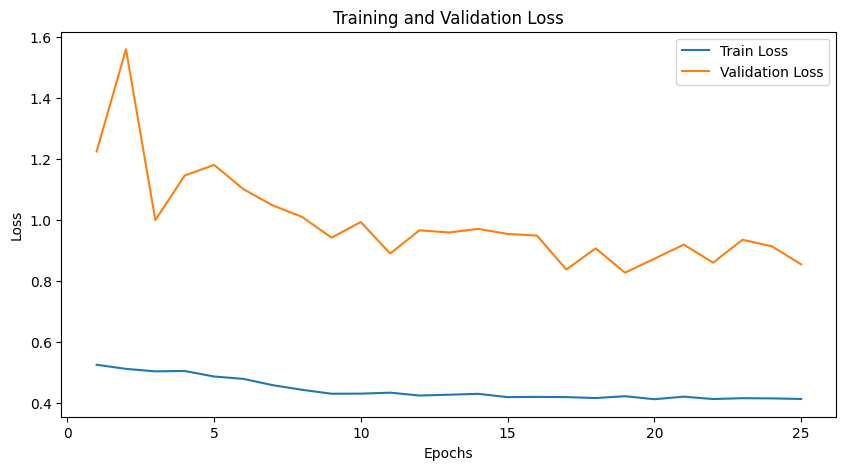

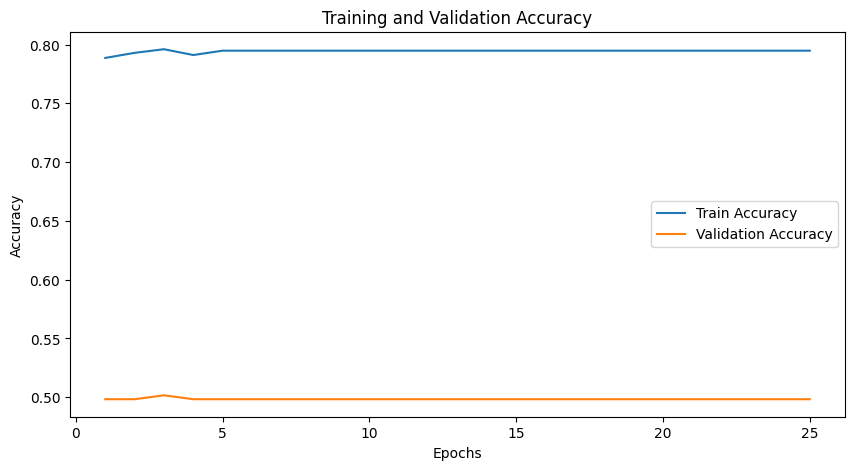

In [12]:
import matplotlib.pyplot as plt
def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
    plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()

def plot_accuracy(train_accuracies, val_accuracies):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train Accuracy')
    plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.show()

# Plot training and validation loss
plot_loss(train_losses, val_losses)

# Plot training and validation accuracy
plot_accuracy(train_acc, val_acc)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


# Plot the confusion matrix
CLASSES = ['Normal', 'Abnormal']  # Define your class names
plot_confusion_matrix(all_labels, all_preds)

Shape of all_labels: (301,)
Shape of all_probs: (301, 2)


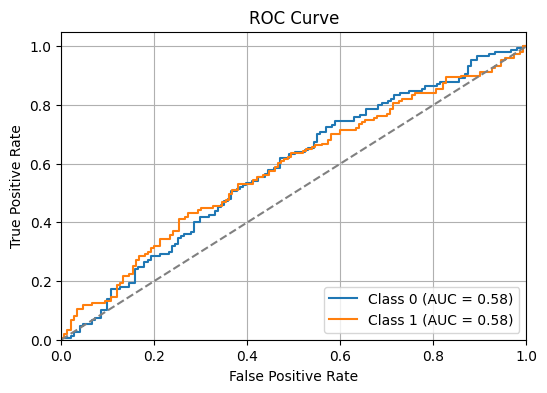

In [23]:
from sklearn.metrics import roc_curve, auc
def plot_roc_curve(model, data_loader, num_classes):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)  # Logits
            probs = torch.softmax(outputs, dim=1)  # Probabilities

            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    # Concatenate all collected batches
    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    print("Shape of all_labels:", all_labels.shape)
    print("Shape of all_probs:", all_probs.shape)

    # ROC curve computation
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves
    plt.figure(figsize=(6, 4))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random baseline
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()


plot_roc_curve(trained_model, val_loader, 2)

# EfficientNet-b1

In [4]:

train_folders = ['training-a', 'training-b', 'training-c', 'training-d', 'training-e', 'training-f']
validation_folder = 'validation'
base_path = '/kaggle/input/physionet-challenge-2016'
    

train_file_paths = []
train_labels = []
val_file_paths = []
val_labels = []


for folder in train_folders:
    data_path = os.path.join(base_path, folder)
    reference_path = os.path.join(data_path, 'REFERENCE.csv')
    file_paths, labels = prepare_dataset(data_path, reference_path)
    train_file_paths.extend(file_paths)
    train_labels.extend(labels)


validation_data_path = os.path.join(base_path, validation_folder)
validation_reference_path = os.path.join(validation_data_path, 'REFERENCE.csv')
val_file_paths, val_labels = prepare_dataset(validation_data_path, validation_reference_path)


train_dataset = HeartSoundDataset(train_file_paths, train_labels, augment=True)
val_dataset = HeartSoundDataset(val_file_paths, val_labels, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


print(f"Train Dataset: {len(train_dataset)} samples")
print(f"Validation Dataset: {len(val_dataset)} samples")

Train Dataset: 3240 samples
Validation Dataset: 301 samples


In [5]:
import timm
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from tqdm import tqdm


class HeartSoundNet(nn.Module):
    def __init__(self, num_classes):
        super(HeartSoundNet, self).__init__()
       
        self.efficientnet = timm.create_model('efficientnet_b1', pretrained=True)
        
        
        self.efficientnet.conv_stem = nn.Conv2d(
            1,  
            self.efficientnet.conv_stem.out_channels, 
            kernel_size=3, 
            stride=2, 
            padding=1, 
            bias=False
        )
        
        
        in_features = self.efficientnet.classifier.in_features  
        self.efficientnet.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)  
        )

    def forward(self, x):
        return self.efficientnet(x)



In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        # Step the scheduler (if provided)
        if scheduler:
            scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train Acc: {epoch_acc:.4f}, Val Acc: {val_acc:.4f}")

        # Save the best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print(f"New best model saved with validation accuracy: {val_acc:.4f}")

    return model, train_losses, val_losses, train_accuracies, val_accuracies


In [7]:
# Model setup and training
num_classes = 2 
learning_rate = 0.0001
num_epochs = 35

model = HeartSoundNet(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Using ReduceLROnPlateau scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1, verbose=True)

trained_model, train_losses, val_losses, train_acc, val_acc = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler=scheduler
) 

model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/35 - Training: 100%|██████████| 102/102 [03:20<00:00,  1.96s/it]


Epoch 1/35, Train Loss: 0.4654, Val Loss: 0.7331, Train Acc: 0.7935, Val Acc: 0.5880
New best model saved with validation accuracy: 0.5880


Epoch 2/35 - Training: 100%|██████████| 102/102 [02:36<00:00,  1.53s/it]


Epoch 2/35, Train Loss: 0.3889, Val Loss: 0.5577, Train Acc: 0.8170, Val Acc: 0.6910
New best model saved with validation accuracy: 0.6910


...

Epoch 33/35, Train Loss: 0.1923, Val Loss: 0.2474, Train Acc: 0.9127, Val Acc: 0.8970


Epoch 34/35 - Training: 100%|██████████| 102/102 [02:29<00:00,  1.46s/it]


Epoch 34/35, Train Loss: 0.1956, Val Loss: 0.2685, Train Acc: 0.9105, Val Acc: 0.8837


Epoch 35/35 - Training: 100%|██████████| 102/102 [02:28<00:00,  1.45s/it]


Epoch 35/35, Train Loss: 0.2036, Val Loss: 0.2233, Train Acc: 0.9065, Val Acc: 0.9136
New best model saved with validation accuracy: 0.9136


In [8]:
def calculate_final_accuracy(model, data_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()  # Set the model to evaluation mode

    correct = 0
    total = 0
    
    with torch.no_grad(): 
        for inputs, labels in tqdm(data_loader, desc="Calculating Final Accuracy"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)  # Get model predictions
            _, predicted = torch.max(outputs, 1)  # Get the class with the highest probability
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total  # Calculate accuracy as a percentage
    print(f'Final Accuracy: {accuracy:.2f}%')
    return accuracy


model.load_state_dict(torch.load("best_model.pth"))  # Load the best saved model
final_accuracy = calculate_final_accuracy(model, val_loader)
print(f'Final Validation Accuracy: {final_accuracy:.2f}%')


/tmp/ipykernel_30/2172268723.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))  # Load the best saved model
Calculatin

Final Accuracy: 91.36%
Final Validation Accuracy: 91.36%


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels

# Evaluate the model and get predictions
all_preds, all_labels = evaluate_model(trained_model, val_loader)


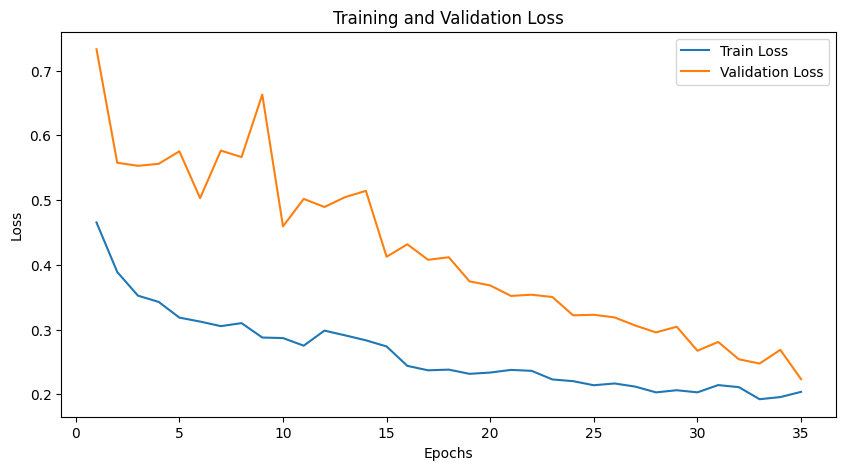

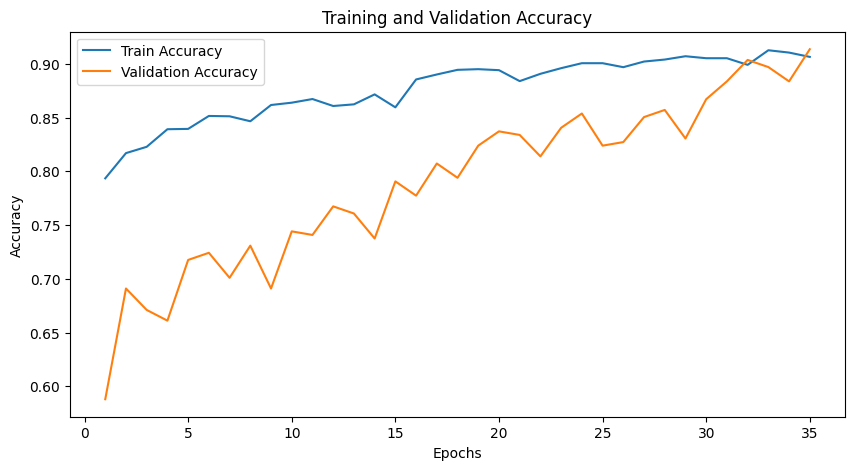

In [12]:
import matplotlib.pyplot as plt
def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
    plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()

def plot_accuracy(train_accuracies, val_accuracies):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train Accuracy')
    plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.show()

# Plot training and validation loss
plot_loss(train_losses, val_losses)

# Plot training and validation accuracy
plot_accuracy(train_acc, val_acc)

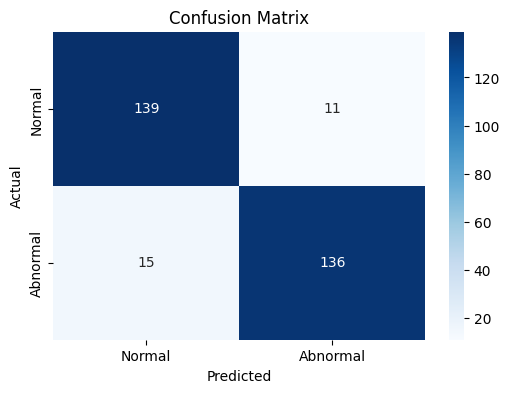

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


# Plot the confusion matrix
CLASSES = ['Normal', 'Abnormal'] 
plot_confusion_matrix(all_labels, all_preds)

Shape of all_labels: (301,)
Shape of all_probs: (301, 2)


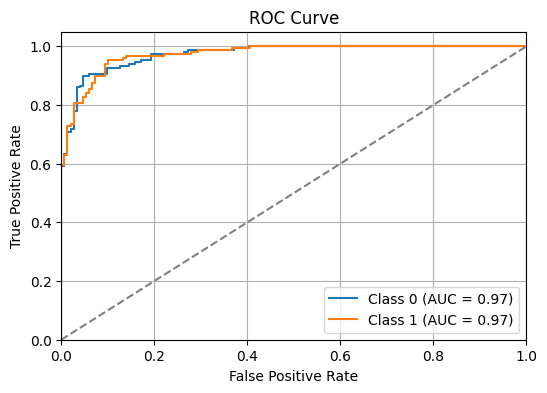

In [14]:
from sklearn.metrics import roc_curve, auc
def plot_roc_curve(model, data_loader, num_classes):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)  # Logits
            probs = torch.softmax(outputs, dim=1)  # Probabilities

            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    # Concatenate all collected batches
    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    print("Shape of all_labels:", all_labels.shape)
    print("Shape of all_probs:", all_probs.shape)

    # ROC curve computation
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves
    plt.figure(figsize=(6, 4))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random baseline
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

plot_roc_curve(trained_model, val_loader, 2)